<a href="https://colab.research.google.com/github/poorvikapalan/machine_learning/blob/main/program3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [14]:
data = load_breast_cancer()
X = data.data
y= data.target

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
k_values = [7, 9, 11, 13, 15]

In [19]:
manhattan_acc = []
minkowski_acc = []

for k in k_values:

    # Manhattan distance
    knn_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_manhattan.fit(X_train, y_train)
    y_pred_manhattan = knn_manhattan.predict(X_test)
    accuracy=accuracy_score(y_test, y_pred_manhattan)
    manhattan_acc.append(accuracy)

    # Minkowski distance (p=3)
    knn_minkowski = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=3)
    knn_minkowski.fit(X_train, y_train)
    y_pred_minkowski = knn_minkowski.predict(X_test)
    accuracy=accuracy_score(y_test, y_pred_minkowski)
    minkowski_acc.append(accuracy)


results = pd.DataFrame({
    "k": k_values,
    "Manhattan Accuracy": manhattan_acc,
    "Minkowski (p=3) Accuracy": minkowski_acc
})

print(results)

    k  Manhattan Accuracy  Minkowski (p=3) Accuracy
0   7            0.938596                  0.956140
1   9            0.964912                  0.956140
2  11            0.964912                  0.982456
3  13            0.964912                  0.982456
4  15            0.964912                  0.973684


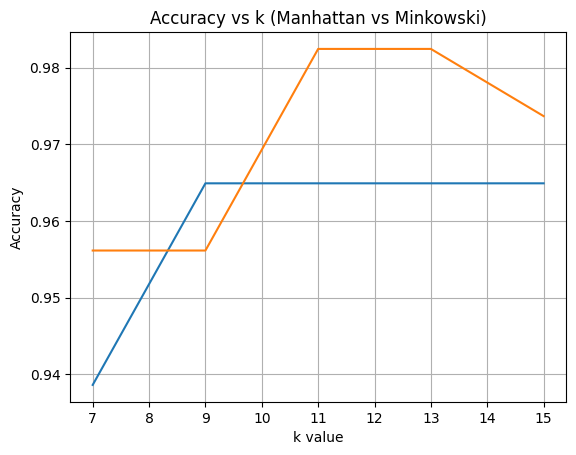

In [20]:
plt.figure()
plt.plot(k_values, manhattan_acc)
plt.plot(k_values, minkowski_acc)
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k (Manhattan vs Minkowski)")
plt.grid()
plt.show()